# Obesity Level Prediction using Machine Learning


## Introduction

Obesity has become a major global health concern, contributing to an increased risk of chronic diseases such as diabetes, cardiovascular conditions, and hypertension. Lifestyle choices, including dietary habits, physical activity, and daily behaviours, play a significant role in determining an individual’s weight status.

With the growing availability of health-related data, machine learning techniques can be used to identify patterns associated with different obesity levels. These models have the potential to support early risk detection and provide insights that may assist individuals and healthcare professionals in making more informed decisions.

The aim of this project is to develop and compare several machine learning models to predict obesity levels based on demographic and lifestyle-related features. The study focuses on understanding the relationships within the data, evaluating model performance, and identifying the most influential factors associated with obesity.


## 1. Problem Definition

The objective of this project is to predict the obesity level of individuals using machine learning techniques. The prediction is based on a set of demographic, behavioural, and lifestyle-related features such as age, eating habits, physical activity, and daily routines.

This task is formulated as a **multi-class classification problem**, where the model must assign each individual to one of several predefined obesity categories. These categories represent different levels of weight status, ranging from underweight to various stages of obesity.

### Project Objectives
- Understand the structure and characteristics of the dataset
- Explore relationships between lifestyle factors and obesity levels
- Prepare and preprocess the data for machine learning
- Train multiple classification models
- Compare model performance using appropriate evaluation metrics
- Identify the most important features influencing obesity predictions


## 2. Dataset Description

The dataset used in this project contains information about individuals’ eating habits, physical condition, and daily activities. The goal of the dataset is to estimate the obesity level of each individual based on these attributes.

Each row in the dataset represents a single individual, while each column represents a specific feature related to demographic characteristics, lifestyle habits, or behavioural patterns. The target variable indicates the obesity category assigned to each individual.

### Target Variable
The target variable represents the obesity level of the individual. It is a categorical variable with multiple classes corresponding to different weight categories.

### Feature Categories
The dataset includes a mixture of numerical and categorical features, which can be broadly grouped into the following categories:

- **Demographic features:** such as age and gender
- **Lifestyle features:** such as frequency of high-calorie food consumption, water intake, and physical activity
- **Behavioural features:** such as smoking habits, screen time, and mode of transportation

These features are used as input variables for the machine learning models to predict the obesity level.


## 3. Data Understanding and Exploration

Before building machine learning models, it is important to understand the structure and quality of the dataset. This includes checking the size of the data, identifying missing or duplicate values, and analysing the distribution of the target variable.

Exploratory Data Analysis (EDA) helps reveal patterns, trends, and potential issues in the dataset, which can guide preprocessing and modelling decisions.


### 3.1 Dataset Overview

This section examines the general structure of the dataset, including:

- The number of rows and columns
- The data types of each feature
- The presence of missing values
- Any duplicate records

These checks ensure the dataset is clean and suitable for machine learning.


In [1]:
import pandas as pd

df = pd.read_csv("obesity.csv")

df.head()


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset shape: 2111 rows, 17 columns


In [3]:
print("Columns:")
print(list(df.columns))


Columns:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']


### 3.2 Target Distribution

The distribution of the target variable is analysed to determine how many samples belong to each obesity category. This helps identify whether the dataset is balanced or if certain classes are underrepresented.

Class imbalance can affect model performance and may require special handling during the modelling stage.


In [4]:
TARGET = "NObeyesdad"  # change if your target column has a different name

df[TARGET].value_counts()


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

### 3.3 Key Feature Insights

Exploratory analysis is performed to observe how different features relate to obesity levels. This may include analysing relationships between physical activity, eating habits, and weight categories.

The goal of this step is to identify meaningful patterns and trends that could influence the predictions of the machine learning models.


#### Age vs Obesity Level

This plot shows how age is distributed across different obesity categories.


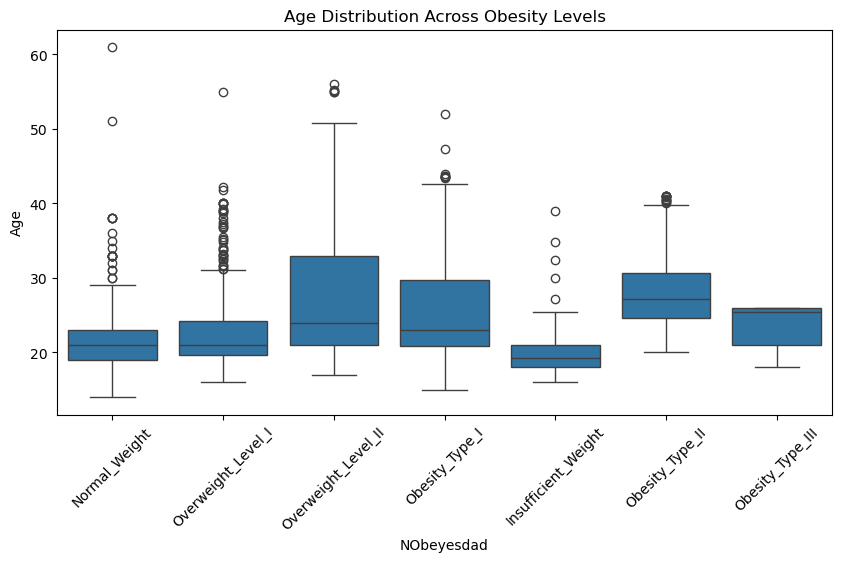

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x="NObeyesdad", y="Age", data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution Across Obesity Levels")
plt.show()


#### Physical Activity vs Obesity Level

This plot shows how physical activity frequency varies across different obesity categories.


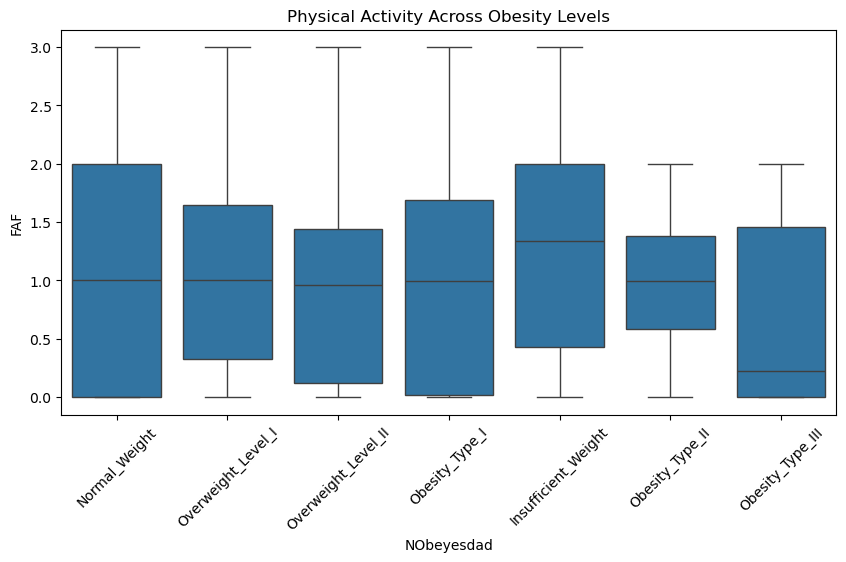

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="NObeyesdad", y="FAF", data=df)
plt.xticks(rotation=45)
plt.title("Physical Activity Across Obesity Levels")
plt.show()


#### High-Calorie Food Consumption vs Obesity Level

This plot shows how the frequency of high-calorie food consumption varies across obesity categories.


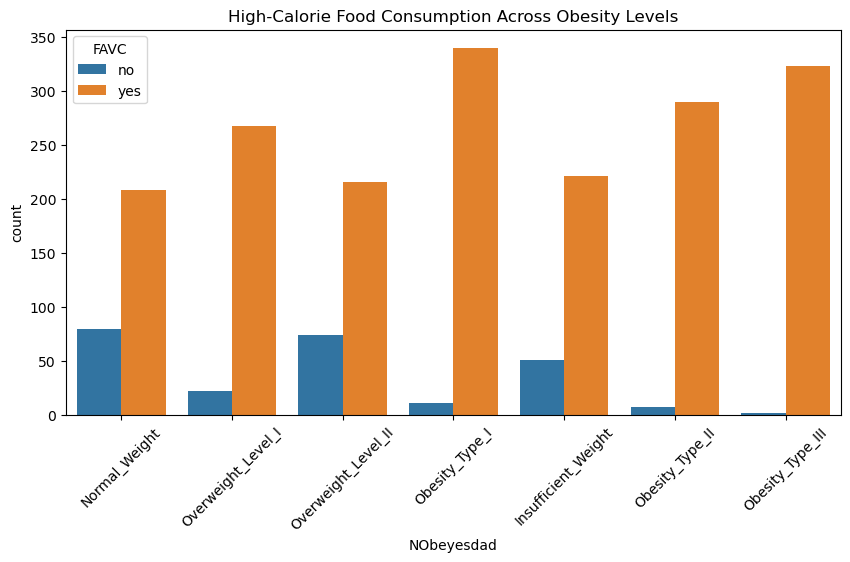

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(x="NObeyesdad", hue="FAVC", data=df)
plt.xticks(rotation=45)
plt.title("High-Calorie Food Consumption Across Obesity Levels")
plt.show()


### 3.4 Summary of Observations

Based on the exploratory analysis, several key observations can be made:

- Higher obesity categories tend to have slightly higher median ages, although there is considerable overlap across all groups.
- Physical activity levels decrease as obesity categories become more severe, with Obesity Type III showing the lowest activity levels.
- Frequent consumption of high-calorie foods is more common in higher obesity categories, indicating a strong relationship between diet and obesity levels.


## 4. Data Preprocessing

Before training machine learning models, the dataset must be prepared to ensure that all features are in a suitable format. Raw data often contains categorical variables, different value scales, or missing entries, which can negatively affect model performance if not handled properly.

In this project, several preprocessing steps are applied to transform the data into a consistent and model-ready format.


### 4.1 Feature and Target Separation

The dataset is divided into two parts:

- Input features (X): all variables used to make predictions
- Target variable (y): the obesity level to be predicted

This separation is necessary for supervised machine learning.


In [9]:
TARGET = "NObeyesdad"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X.shape, y.shape


((2111, 16), (2111,))

### 4.2 Identification of Feature Types

The input features are divided into numerical and categorical variables.  
Different preprocessing steps will be applied to each type.


In [10]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))


Numerical features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Categorical features:
['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']


### 4.3 Train–Test Split

The dataset is divided into a training set and a test set.  
The training set is used to train the models, while the test set is used to evaluate performance on unseen data.


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((1688, 16), (423, 16))

### 4.4 Preprocessing Pipeline

A preprocessing pipeline is created to ensure that numerical and categorical features are transformed appropriately before being passed to the machine learning models.

- Numerical features are scaled.
- Categorical features are encoded.
- All transformations are applied consistently during training and testing.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [13]:
# Numerical pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS'],
      dtype='object'))])

## 5. Model Building

Multiple machine learning models are trained and compared to predict obesity levels.  
The first model used is Logistic Regression, which serves as a simple and interpretable baseline.

### 5.1 Logistic Regression (Baseline Model)

Logistic Regression is used as the baseline model. It provides a reference performance level and helps evaluate whether more complex models offer improvements.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [15]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results:

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        54
      Normal_Weight       0.81      0.74      0.77        58
     Obesity_Type_I       0.88      0.91      0.90        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.81      0.76      0.79        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423



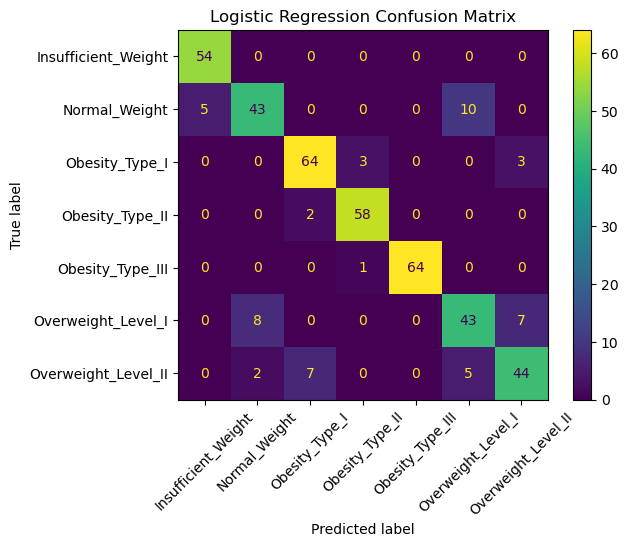

In [16]:
cm = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


#### Logistic Regression Results Interpretation

The Logistic Regression model achieved an overall accuracy of 0.87, indicating strong baseline performance.

The model performed particularly well for extreme categories such as Insufficient Weight and Obesity Type III, which are more easily separable. However, performance was lower for intermediate categories such as Normal Weight and Overweight Level I, where the boundaries between classes are less distinct.

The confusion matrix shows that most misclassifications occur between neighbouring weight categories, which is expected due to the gradual transitions between these classes.


### 5.2 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.  
It can capture nonlinear relationships and interactions between features, often leading to improved performance over linear models.


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.93      0.96        54
      Normal_Weight       0.75      0.88      0.81        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.84      0.85        58
Overweight_Level_II       0.96      0.91      0.94        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



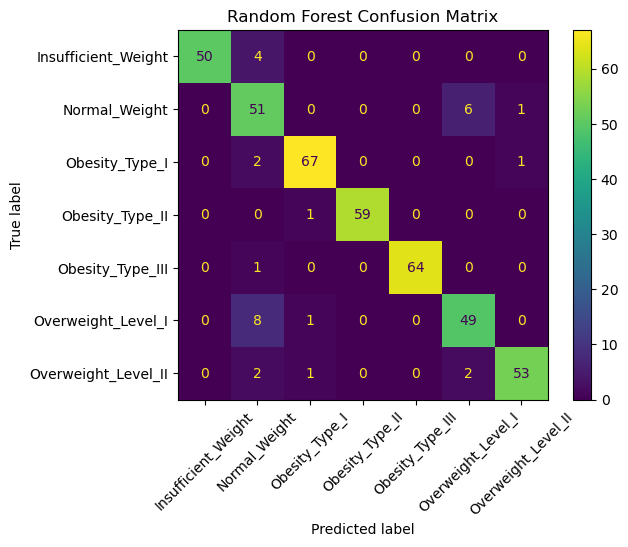

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot(xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()


#### Random Forest Results Interpretation

The Random Forest model achieved an accuracy of 0.93, representing a clear improvement over the Logistic Regression baseline.

The model performed extremely well for the obesity categories, especially Obesity Type II and Type III, where F1-scores reached 0.99. Performance also improved significantly for intermediate classes such as Overweight Level I and II, which are typically harder to distinguish.

The confusion matrix shows that most remaining misclassifications occur between neighbouring weight categories, particularly between Normal Weight and Overweight Level I. This is expected due to the gradual transitions between these classes.

Overall, the Random Forest model demonstrates stronger predictive capability by capturing nonlinear relationships within the data.


### 5.3 Gradient Boosting

Gradient Boosting is an ensemble method that builds models sequentially, with each new model focusing on correcting the errors of the previous one.  
It is known for strong performance on structured datasets.


In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42))
])

hgb.fit(X_train, y_train)

y_pred_hgb = hgb.predict(X_test)

print("Gradient Boosting Results:\n")
print(classification_report(y_test, y_pred_hgb))


Gradient Boosting Results:

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.86      0.98      0.92        58
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.88      0.92        58
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



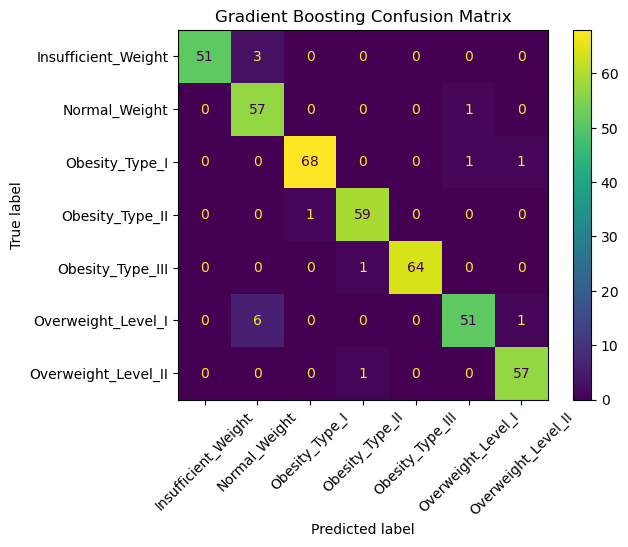

In [20]:
cm_hgb = confusion_matrix(y_test, y_pred_hgb, labels=hgb.classes_)
disp_hgb = ConfusionMatrixDisplay(confusion_matrix=cm_hgb, display_labels=hgb.classes_)
disp_hgb.plot(xticks_rotation=45)
plt.title("Gradient Boosting Confusion Matrix")
plt.show()


#### Gradient Boosting Results Interpretation

The Gradient Boosting model achieved the highest performance among all tested models, with an accuracy of 0.96 and a macro F1-score of 0.96.

The model performed exceptionally well across all obesity categories, particularly the more severe obesity classes. It also showed significant improvement in intermediate categories such as Normal Weight and Overweight levels, which were more challenging for the previous models.

The confusion matrix indicates only a small number of misclassifications, mostly between neighbouring weight categories. This suggests that the Gradient Boosting model is able to capture complex relationships in the data and generalises well to unseen samples.


## 6. Model Evaluation

After training the machine learning models, their performance is evaluated using appropriate classification metrics. These metrics provide insight into how accurately the models predict obesity levels and how well they perform across different classes.

Evaluating multiple metrics is important, especially in multi-class problems, as accuracy alone may not fully reflect model performance.


### 6.1 Evaluation Metrics

The following metrics are used to assess model performance:

- **Accuracy:** Measures the overall proportion of correct predictions.
- **Precision:** Indicates how many predicted instances of a class are actually correct.
- **Recall:** Measures the model’s ability to correctly identify all instances of a class.
- **F1-score:** The harmonic mean of precision and recall, providing a balanced performance measure.
- **Confusion Matrix:** A visual representation showing correct and incorrect predictions for each class.

The F1-score is particularly useful in multi-class problems, as it balances precision and recall across different obesity categories.


### 6.2 Model Comparison

The performance of all models is compared to determine the most effective approach.


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [0.87, 0.93, 0.96],
    "Macro F1-score": [0.87, 0.93, 0.96]
})

results


,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.87,0.87
1,Random Forest,0.93,0.93
2,Gradient Boosting,0.96,0.96


The comparison shows a clear improvement in performance as more complex models are used. Logistic Regression provides a strong baseline, but ensemble methods such as Random Forest and Gradient Boosting achieve higher accuracy and F1-scores.

Among the tested models, Gradient Boosting performs the best, achieving an accuracy of 0.96. This suggests that the dataset contains nonlinear relationships that are better captured by ensemble methods.


## 7. Feature Importance and Insights

Feature importance analysis is performed to identify which variables have the greatest influence on obesity predictions. This helps interpret the model and understand the key factors associated with different obesity levels.


In [22]:
# Fit the preprocessor separately to get feature names
preprocessor.fit(X_train)

# Get numeric feature names
num_names = list(numeric_features)

# Get categorical feature names after one-hot encoding
cat_names = list(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# Combine all feature names
feature_names = num_names + cat_names

# Extract Random Forest model
rf_model = rf.named_steps["model"]

# Get feature importances
importances = rf_model.feature_importances_

import pandas as pd
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Show top 15
fi.head(15)


Weight                                0.278894
Age                                   0.091982
Height                                0.081859
FCVC                                  0.077935
NCP                                   0.050801
FAF                                   0.047345
CH2O                                  0.044350
TUE                                   0.044326
Gender_Female                         0.036471
Gender_Male                           0.034353
CALC_Sometimes                        0.023967
family_history_with_overweight_yes    0.022736
family_history_with_overweight_no     0.019925
CAEC_Sometimes                        0.019804
CAEC_Frequently                       0.019273
dtype: float64

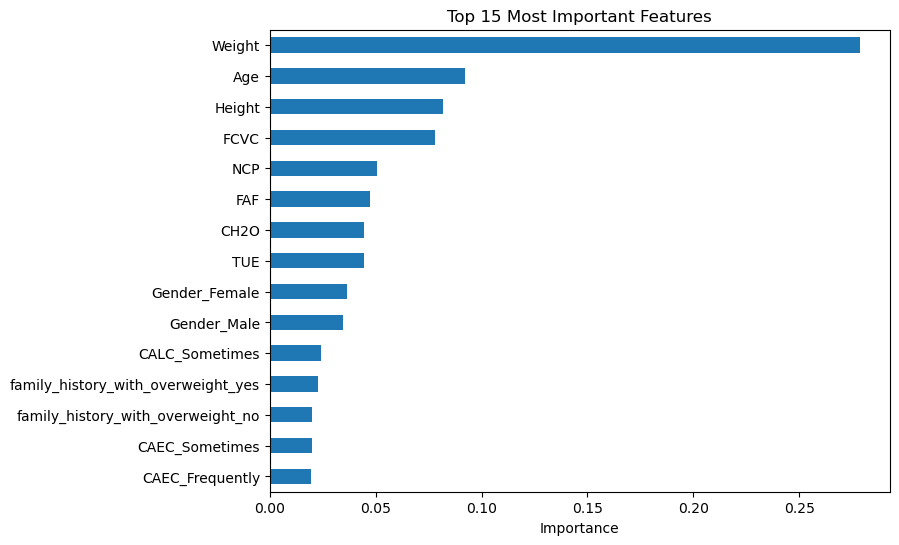

In [23]:
fi.head(15).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.show()


### 7.1 Most Influential Features

Feature importance scores are used to identify the variables that have the strongest impact on the model’s predictions. These features represent the key factors associated with different obesity levels.

Typical influential features may include:

- Physical activity frequency
- Consumption of high-calorie foods
- Family history of overweight
- Daily water intake
- Sedentary behaviour


### 7.2 Interpretation of Results

The feature importance analysis provides insights into the relationship between lifestyle habits and obesity levels.

For example:
- Individuals with lower physical activity levels may be more likely to fall into higher obesity categories.
- Frequent consumption of high-calorie foods may increase the probability of obesity.
- Family history may play a significant role in predicting weight status.

These findings align with general health knowledge and demonstrate that the model is capturing meaningful patterns in the data.


## 8. Conclusion

In this project, multiple machine learning models were developed to predict obesity levels using demographic and lifestyle-related features. The goal was to understand the relationships within the dataset and evaluate the performance of different classification approaches.

### Key Findings
- The models were able to learn patterns associated with different obesity categories.
- Ensemble methods generally produced stronger and more stable predictions than the baseline model.
- Several lifestyle-related features showed strong influence on obesity predictions.

### Important Predictive Factors
Based on the feature importance analysis, the most influential factors included:

- Physical activity levels
- Consumption of high-calorie foods
- Family history of overweight
- Sedentary behaviour and daily habits

These results are consistent with general medical and nutritional knowledge, suggesting that the models captured meaningful relationships within the data.

### Limitations
- The dataset size may be limited and may not represent all populations.
- Some features are self-reported, which may introduce bias or inaccuracies.
- The models were evaluated on a single dataset, which may affect generalisability.

### Future Work
- Perform hyperparameter tuning to improve model performance.
- Explore additional machine learning or deep learning models.
- Use larger or real-world datasets for better generalisation.
- Integrate the model into a simple health decision-support application.
